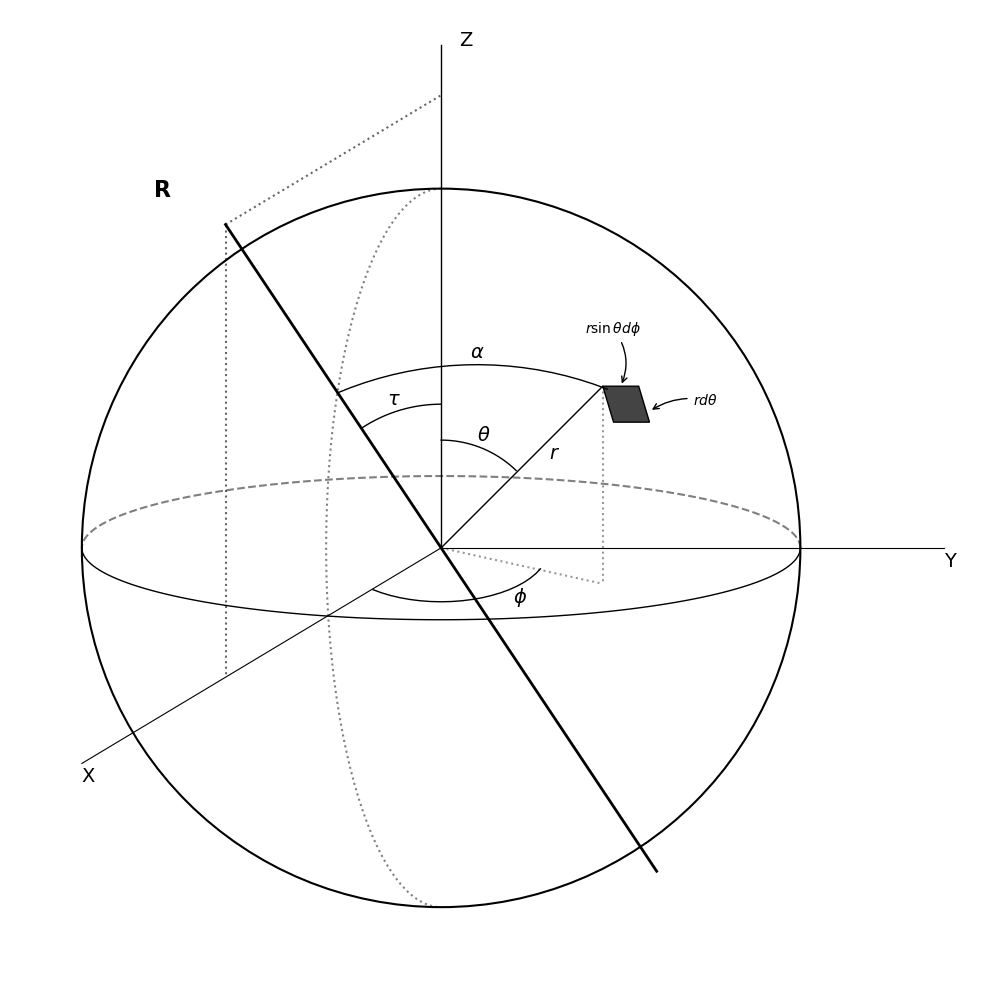

In [98]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

def draw_exact_spherical_diagram():
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    
    # --- 1. CORE SPHERE ---
    # Outer boundary
    circle = plt.Circle((0, 0), 1, color='black', fill=False, lw=1.5)
    ax.add_artist(circle)
    
    # Main Equator (Solid front, dashed back)
    theta_eq = np.linspace(0, np.pi, 100)
    ax.plot(np.cos(theta_eq), -0.2 * np.sin(theta_eq), 'k-', lw=1) # Front
    ax.plot(np.cos(theta_eq), 0.2 * np.sin(theta_eq), 'k--', alpha=0.5) # Back

    # --- 2. CARTESIAN AXES ---
    # Z-axis
    ax.plot([0, 0], [0, 1.4], 'k-', lw=1)
    ax.text(0.05, 1.4, 'Z', fontsize=14)
    
    # Y-axis
    ax.plot([0, 1.4], [0, 0], 'k-', lw=0.8)
    ax.text(1.4, -0.05, 'Y', fontsize=14)
    
    # X-axis (Projected)
    ax.plot([0, -1], [0, -0.6], 'k-', lw=0.8)
    ax.text(-1, -0.65, 'X', fontsize=14)

    # --- 3. THE R-AXIS AND ANGLES (XZ PLANE) ---
    # R-axis tilted into the back-left quadrant
    ax.plot([0.6, -0.6], [-1.2/8*6, 0.9], 'k-', lw=2)
    ax.text(-0.8, 0.98, 'R', fontsize=16, fontweight='bold')
    t = 1
    ax.plot([ t * -0.6, t *  0], [ t * 0.9,  t *( 0.9 + 0.6**2)], 'k:', alpha=0.6) # Dotted to Z-axis (height)
    ax.plot([ t * -0.6,  t * -0.6], [ t * 0.9,  t * -0.6**2], 'k:', alpha=0.6) # Dotted to X-axis

    # Tilted Equator 
    theta_eq = np.linspace(np.pi/2, 3*np.pi/2, 100)
    ax.plot(0.32 * np.cos(theta_eq),  np.sin(theta_eq), 'k:', alpha=0.5) 

    # --- 4. THE DIFFERENTIAL ELEMENT & GUIDES ---
    # Positioning the patch
    p_angle = 1.1 # theta
    z_h = np.cos(p_angle)
    r_lat = 1

    # The Patch (Dark Trapezoid)
    # Define 4 corners for the differential area
    pts = np.array([
        [0.45, 0.45], [0.55, 0.45], 
        [0.58, 0.35], [0.48, 0.35]
    ])
    patch = Polygon(pts, closed=True, color='#444444', ec='black')
    ax.add_patch(patch)

    # Labels for the patch with curved arrows (annotations)
    ax.annotate(r'$r \sin \theta d \phi$', xy=(0.5, 0.45), xytext=(0.4, 0.6),
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=-0.3"))
    ax.annotate(r'$r d\theta$', xy=(0.58, 0.38), xytext=(0.7, 0.4),
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.2"))

    # --- 5. RADIUS AND PHI ---
    # Radius vector to the patch
    ax.plot([0, 0.45], [0, 0.45], 'k-', lw=1)
    ax.text(0.3, 0.25, r'$r$', fontsize=14)

    # Theta angle
    theta_arc = np.linspace(np.pi/2, 0.8, 20)
    ax.plot(0.3 * np.cos(theta_arc), 0.3 * np.sin(theta_arc), 'k-', lw=1)
    ax.text(0.1, 0.30, r'$\theta$', fontsize=14)
    
    # Phi angle (on the bottom)
    phi_arc = np.linspace(-2.87*np.pi/4, -0.4, 20)
    ax.plot(0.3 * np.cos(phi_arc), 0.15 * np.sin(phi_arc), 'k-', lw=1)
    ax.text(0.2, -0.15, r'$\phi$', fontsize=14)

    # Drop lines for perspective
    ax.plot([0.45, 0.45], [0.45, -0.1], 'k:', alpha=0.4)
    ax.plot([0, 0.45], [0., -0.1], 'k:', alpha=0.4)
    
    # Angle alpha (between R and r)
    alpha_arc = np.linspace(1.2, 1.97, 20)
    ax.plot(1 * np.cos(alpha_arc)+0.1, 1 * np.sin(alpha_arc)-0.49, 'k-', lw=1)
    ax.text(0.08, 0.53, r'$\alpha$', fontsize=14)
    
    # Angle tau
    tau_arc = np.linspace(np.pi/2, 2.15, 30)
    ax.plot(0.4 * np.cos(tau_arc), 0.4 * np.sin(tau_arc), 'k-', lw=1)
    ax.text(-0.15, 0.4, r'$\tau$', fontsize=14)

    # Final Formatting
    ax.set_xlim(-1.2, 1.5)
    ax.set_ylim(-1.2, 1.5)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    fig.savefig("coordinate_plot.pdf")


draw_exact_spherical_diagram()